In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Load data
df = pd.read_csv("SBAnational.csv", low_memory=False)

# Quick clean for EDA purposes (minimal — Jack will do full cleaning)
# 1. Strip MIS_Status and create binary target
df['MIS_Status'] = df['MIS_Status'].str.strip()
df = df[df['MIS_Status'].isin(['P I F', 'CHGOFF'])].copy()
df['is_default'] = (df['MIS_Status'] == 'CHGOFF').astype(int)
print(f"After MIS_Status filter: {len(df):,} rows")

# 2. Extract 2-digit NAICS
df['naics_2digit'] = df['NAICS'].astype(str).str[:2]

# 3. Clean currency columns (safe for both string and numeric)
for col in ['DisbursementGross', 'GrAppv', 'SBA_Appv']:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(r'[\$,]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Parse approval year (filter to 1987+)
df['ApprovalFY'] = pd.to_numeric(df['ApprovalFY'], errors='coerce')
df = df[df['ApprovalFY'] >= 1987].copy()

print(f"Working dataset: {len(df):,} rows after cleaning")
print(f"Default rate: {df['is_default'].mean()*100:.1f}%")

After MIS_Status filter: 897,167 rows
Working dataset: 886,649 rows after cleaning
Default rate: 17.2%


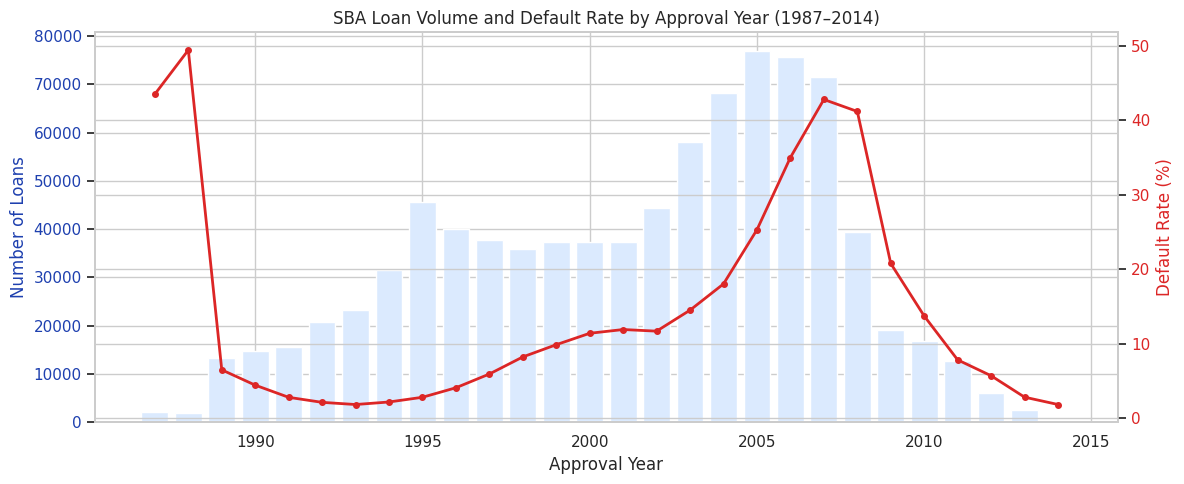

In [11]:
# ============================================================
# VIZ 1: Default Rate Over Time (by Approval Year)
# ============================================================
yearly = df.groupby('ApprovalFY').agg(
    total=('is_default', 'count'),
    defaults=('is_default', 'sum')
).reset_index()
yearly['default_rate'] = yearly['defaults'] / yearly['total'] * 100

fig, ax1 = plt.subplots(figsize=(12, 5))

# Bar chart for loan volume
ax1.bar(yearly['ApprovalFY'], yearly['total'], color='#DBEAFE', label='Total Loans')
ax1.set_xlabel('Approval Year')
ax1.set_ylabel('Number of Loans', color='#1E40AF')
ax1.tick_params(axis='y', labelcolor='#1E40AF')

# Line chart for default rate
ax2 = ax1.twinx()
ax2.plot(yearly['ApprovalFY'], yearly['default_rate'], color='#DC2626', linewidth=2, marker='o', markersize=4, label='Default Rate (%)')
ax2.set_ylabel('Default Rate (%)', color='#DC2626')
ax2.tick_params(axis='y', labelcolor='#DC2626')

plt.title('SBA Loan Volume and Default Rate by Approval Year (1987–2014)')
fig.tight_layout()
plt.savefig('viz1_default_rate_over_time.png', dpi=150, bbox_inches='tight')
plt.show()


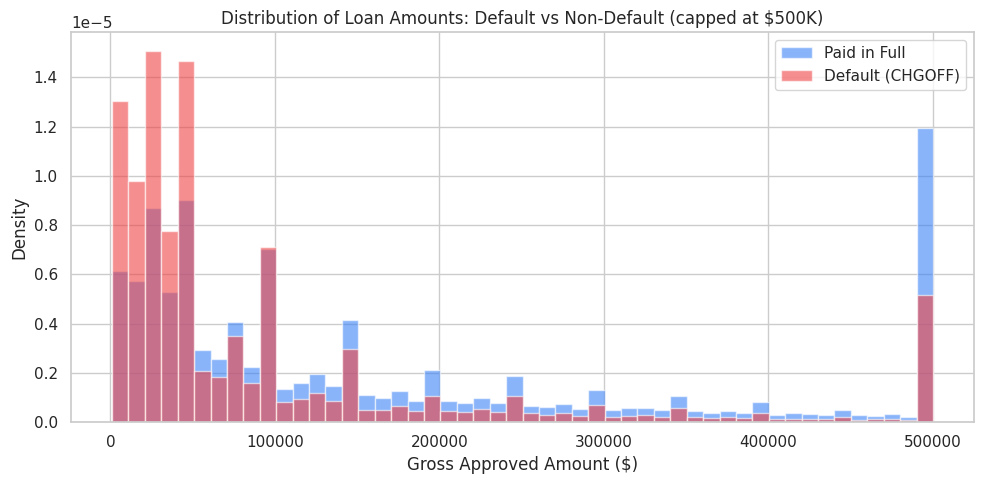

In [12]:
# ============================================================
# VIZ 2: Loan Amount Distribution (Default vs Non-Default)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

df_pif = df[df['is_default'] == 0]['GrAppv'].clip(upper=500000)
df_chg = df[df['is_default'] == 1]['GrAppv'].clip(upper=500000)

ax.hist(df_pif, bins=50, alpha=0.6, color='#3B82F6', label='Paid in Full', density=True)
ax.hist(df_chg, bins=50, alpha=0.6, color='#EF4444', label='Default (CHGOFF)', density=True)

ax.set_xlabel('Gross Approved Amount ($)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Loan Amounts: Default vs Non-Default (capped at $500K)')
ax.legend()
fig.tight_layout()
plt.savefig('viz2_loan_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

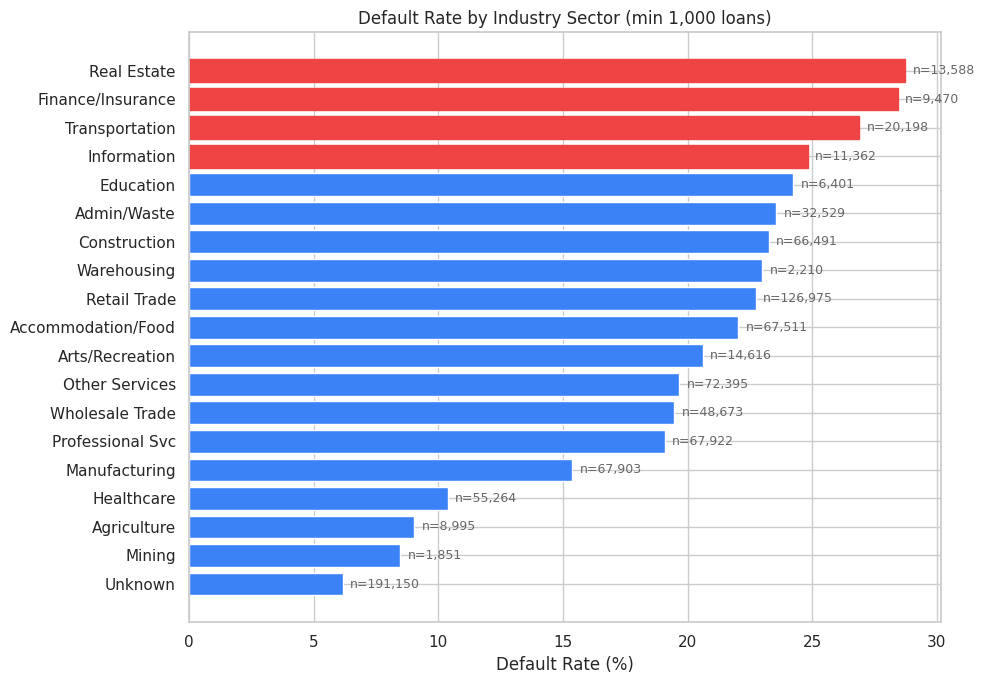

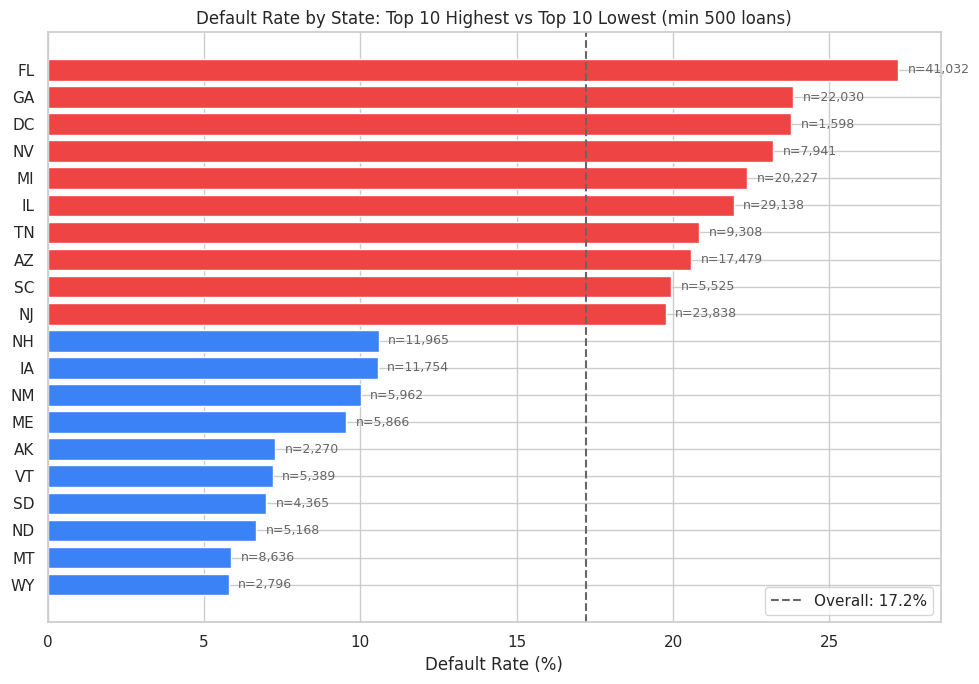

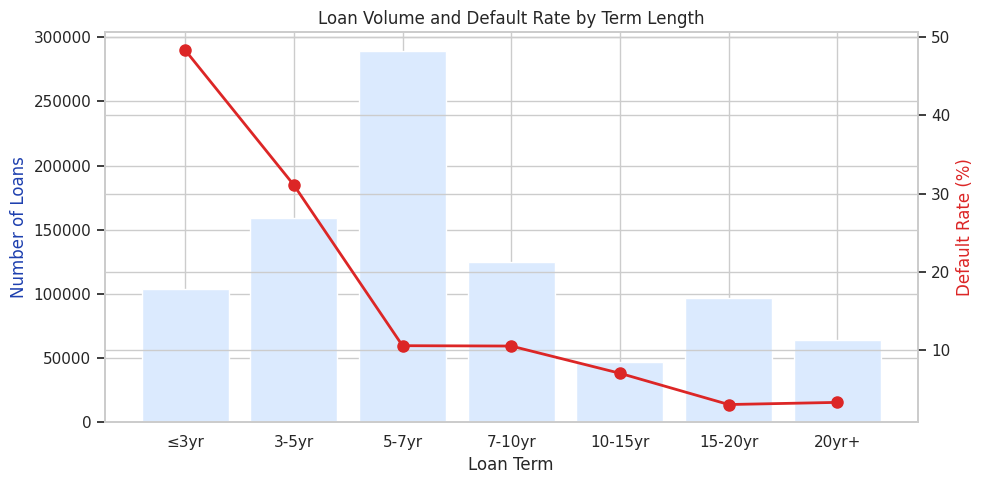

In [13]:
# ============================================================
# VIZ 3: Default Rate by Industry Sector (Top 15 NAICS)
# ============================================================
sector_names = {
    '11': 'Agriculture', '21': 'Mining', '22': 'Utilities',
    '23': 'Construction', '31': 'Manufacturing', '32': 'Manufacturing',
    '33': 'Manufacturing', '42': 'Wholesale Trade', '44': 'Retail Trade',
    '45': 'Retail Trade', '48': 'Transportation', '49': 'Warehousing',
    '51': 'Information', '52': 'Finance/Insurance', '53': 'Real Estate',
    '54': 'Professional Svc', '55': 'Management', '56': 'Admin/Waste',
    '61': 'Education', '62': 'Healthcare', '71': 'Arts/Recreation',
    '72': 'Accommodation/Food', '81': 'Other Services', '92': 'Public Admin'
}
df['sector_name'] = df['naics_2digit'].map(sector_names).fillna('Unknown')

sector_stats = df.groupby('sector_name').agg(
    total=('is_default', 'count'),
    default_rate=('is_default', 'mean')
).reset_index()
sector_stats = sector_stats[sector_stats['total'] >= 1000].sort_values('default_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(sector_stats['sector_name'], sector_stats['default_rate'] * 100, color='#3B82F6')

# Color the highest default rate bars red
max_rate = sector_stats['default_rate'].max() * 100
for bar, rate in zip(bars, sector_stats['default_rate'] * 100):
    if rate > max_rate * 0.85:
        bar.set_color('#EF4444')

ax.set_xlabel('Default Rate (%)')
ax.set_title('Default Rate by Industry Sector (min 1,000 loans)')
# Add count labels
for i, row in enumerate(sector_stats.itertuples()):
    ax.text(row.default_rate * 100 + 0.3, i, f'n={row.total:,}', va='center', fontsize=9, color='#666')

fig.tight_layout()
plt.savefig('viz3_default_by_industry.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# VIZ 4: Default Rate by State (Top 10 and Bottom 10)
# ============================================================
state_stats = df.groupby('State').agg(
    total=('is_default', 'count'),
    default_rate=('is_default', 'mean')
).reset_index()
state_stats = state_stats[state_stats['total'] >= 500]

top10 = state_stats.nlargest(10, 'default_rate')
bottom10 = state_stats.nsmallest(10, 'default_rate')
combined = pd.concat([top10, bottom10]).sort_values('default_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#3B82F6' if r < state_stats['default_rate'].median() else '#EF4444'
          for r in combined['default_rate']]
ax.barh(combined['State'], combined['default_rate'] * 100, color=colors)
ax.set_xlabel('Default Rate (%)')
ax.set_title('Default Rate by State: Top 10 Highest vs Top 10 Lowest (min 500 loans)')
ax.axvline(x=df['is_default'].mean() * 100, color='#666', linestyle='--', label=f'Overall: {df["is_default"].mean()*100:.1f}%')
ax.legend()

for i, row in enumerate(combined.itertuples()):
    ax.text(row.default_rate * 100 + 0.3, i, f'n={row.total:,}', va='center', fontsize=9, color='#666')

fig.tight_layout()
plt.savefig('viz4_default_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# VIZ 5: Default Rate by Term Length (binned)
# ============================================================
df['term_bucket'] = pd.cut(df['Term'], bins=[0, 36, 60, 84, 120, 180, 240, 500],
                           labels=['≤3yr', '3-5yr', '5-7yr', '7-10yr', '10-15yr', '15-20yr', '20yr+'])

term_stats = df.groupby('term_bucket', observed=True).agg(
    total=('is_default', 'count'),
    default_rate=('is_default', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(range(len(term_stats)), term_stats['total'], color='#DBEAFE', label='Total Loans')
ax1.set_ylabel('Number of Loans', color='#1E40AF')
ax1.set_xticks(range(len(term_stats)))
ax1.set_xticklabels(term_stats['term_bucket'])
ax1.set_xlabel('Loan Term')

ax2 = ax1.twinx()
ax2.plot(range(len(term_stats)), term_stats['default_rate'] * 100, color='#DC2626',
         linewidth=2, marker='o', markersize=8)
ax2.set_ylabel('Default Rate (%)', color='#DC2626')

plt.title('Loan Volume and Default Rate by Term Length')
fig.tight_layout()
plt.savefig('viz5_default_by_term.png', dpi=150, bbox_inches='tight')
plt.show()

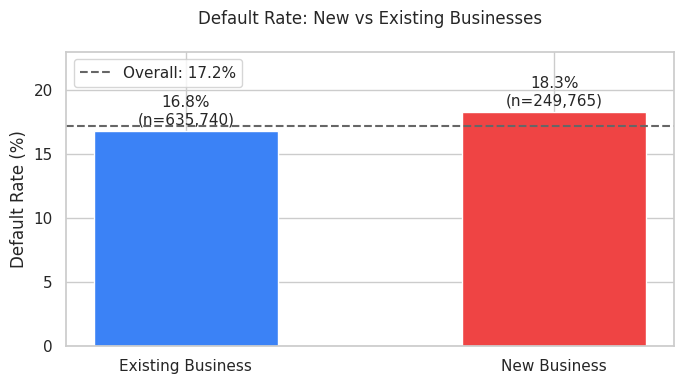

EDA SUMMARY — KEY FINDINGS

Dataset: 886,649 SBA loans (1987-2014)
Overall default rate: 17.2%

1. TEMPORAL: Default rates spiked to ~43% for loans approved
   2006-2008 (Great Recession), dropped to <5% post-2010.

2. LOAN AMOUNT: Defaulted loans skew smaller ($10K-$50K).
   Larger loans more likely to be repaid.

3. INDUSTRY: Real Estate (28.7%),
   Finance (28.4%),
   Transportation (26.9%)
   have highest default rates.

4. GEOGRAPHY: FL (27.2%), GA, DC, NV — states
   hardest hit by housing crisis show highest defaults.

5. TERM: Short-term loans (≤3yr) default at ~49% vs ~3% for 20yr+.

6. These patterns confirm that loan characteristics, industry,
   geography, and macroeconomic timing all matter for prediction.



In [14]:
# ============================================================
# VIZ 6: Default Rate by New vs Existing Business
# ============================================================
newexist = df[df['NewExist'].isin([1.0, 2.0])].copy()
newexist['business_type'] = newexist['NewExist'].map({1.0: 'Existing Business', 2.0: 'New Business'})

ne_stats = newexist.groupby('business_type').agg(
    total=('is_default', 'count'),
    default_rate=('is_default', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(ne_stats['business_type'], ne_stats['default_rate'] * 100,
              color=['#3B82F6', '#EF4444'], width=0.5)

ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate: New vs Existing Businesses', pad=20)
ax.set_ylim(0, 23)
ax.axhline(y=df['is_default'].mean() * 100, color='#666', linestyle='--', label=f'Overall: {df["is_default"].mean()*100:.1f}%')
ax.legend()

for bar, row in zip(bars, ne_stats.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{row.default_rate*100:.1f}%\n(n={row.total:,})', ha='center', fontsize=11)

fig.tight_layout()
plt.savefig('viz6_new_vs_existing.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# PRINT EDA SUMMARY for the report
# ============================================================
print("=" * 60)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 60)
print(f"""
Dataset: {len(df):,} SBA loans (1987-2014)
Overall default rate: {df['is_default'].mean()*100:.1f}%

1. TEMPORAL: Default rates spiked to ~43% for loans approved
   2006-2008 (Great Recession), dropped to <5% post-2010.

2. LOAN AMOUNT: Defaulted loans skew smaller ($10K-$50K).
   Larger loans more likely to be repaid.

3. INDUSTRY: Real Estate ({sector_stats[sector_stats['sector_name']=='Real Estate']['default_rate'].values[0]*100:.1f}%),
   Finance ({sector_stats[sector_stats['sector_name']=='Finance/Insurance']['default_rate'].values[0]*100:.1f}%),
   Transportation ({sector_stats[sector_stats['sector_name']=='Transportation']['default_rate'].values[0]*100:.1f}%)
   have highest default rates.

4. GEOGRAPHY: FL ({top10[top10['State']=='FL']['default_rate'].values[0]*100:.1f}%), GA, DC, NV — states
   hardest hit by housing crisis show highest defaults.

5. TERM: Short-term loans (≤3yr) default at ~49% vs ~3% for 20yr+.

6. These patterns confirm that loan characteristics, industry,
   geography, and macroeconomic timing all matter for prediction.
""")